# Deep Learning for State Poverty Rate Prediction

**Objective:** Apply deep learning methods to predict US state poverty rates using socio-economic predictors.

**Methodology:** Following the approach from the Somalia poverty study (Nature Scientific Reports 2024), we implement:
- Neural Networks with keras
- Random Forest for comparison
- Feature importance analysis
- Model performance evaluation (RMSE, R², MAE)

**Data:** State-level cross-sectional data (n=50) for 2023

## 1. Setup and Data Loading

In [1]:
# Install required packages
install.packages(c("keras3", "tidyverse", "randomForest", "caret", "MLmetrics", "gridExtra"))

library(keras3)
library(tidyverse)
library(caret)
library(MLmetrics)

trying URL 'https://cran.rstudio.com/bin/macosx/sonoma-arm64/contrib/4.6/keras3_1.5.1.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/sonoma-arm64/contrib/4.6/tidyverse_2.0.0.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/sonoma-arm64/contrib/4.6/randomForest_4.7-1.2.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/sonoma-arm64/contrib/4.6/caret_7.0-1.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/sonoma-arm64/contrib/4.6/MLmetrics_1.1.3.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/sonoma-arm64/contrib/4.6/gridExtra_2.3.1.tgz'



The downloaded binary packages are in
	/var/folders/dv/gmvbpr29383_tr9nbd5g1r9c0000gq/T//Rtmp92krrw/downloaded_packages
── Attaching core tidyverse packages ─────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors
Loading required package: lattice

Attaching package: ‘caret’

The following object is masked from ‘package:purrr’:

    lift


Attaching package: ‘MLmetrics’

The following 

In [3]:
data <- read_csv("/Users/winniex/Desktop/WDS_2026_AI_HOME/Project/dataset - Sheet1 (2).csv")
# Display structure
summary(data)

Rows: 51 Columns: 31
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): State
dbl (30): pop_dens, unemploy_rate, avg_rent, apart_size, log_income, avg_wage_hr, log_med_home_price, avg_live_conver, avg_live_groc, avg_live_hous, avg_live_uti, ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


       State       pop_dens       unemploy_rate      avg_rent      apart_size      log_income     avg_wage_hr    log_med_home_price avg_live_conver  avg_live_groc  
 Length   :51   Min.   :    1.0   Min.   :2.100   Min.   : 919   Min.   :471.0   Min.   :4.706   Min.   :24.43   Min.   :5.360      Min.   : 85.30   Min.   : 94.0  
 N.unique :51   1st Qu.:   47.5   1st Qu.:3.400   1st Qu.:1129   1st Qu.:669.5   1st Qu.:4.784   1st Qu.:29.26   1st Qu.:5.455      1st Qu.: 91.75   1st Qu.: 97.0  
 N.blank  : 0   Median :  106.0   Median :4.200   Median :1364   Median :698.0   Median :4.812   Median :31.21   Median :5.590      Median : 96.50   Median :100.0  
 Min.nchar: 4   Mean   :  412.1   Mean   :4.067   Mean   :1480   Mean   :690.1   Mean   :4.824   Mean   :32.40   Mean   :5.598      Mean   :104.00   Mean   :101.3  
 Max.nchar:20   3rd Qu.:  226.5   3rd Qu.:4.650   3rd Qu.:1736   3rd Qu.:720.5   3rd Qu.:4.855   3rd Qu.:34.44   3rd Qu.:5.700      3rd Qu.:112.30   3rd Qu.:103.0  
          

## 2. Data Preparation

In [4]:
# Remove State column (keep only numeric predictors and outcome)
# Outcome variable is 'poverty'
data_clean <- data %>%
  select(-State) %>%
  na.omit()

# Check final dimensions
cat("Final dataset:", nrow(data_clean), "observations,", ncol(data_clean), "variables\n")
cat("Outcome variable: poverty\n")
cat("Number of predictors:", ncol(data_clean) - 1, "\n")

Final dataset: 51 observations, 30 variables
Outcome variable: poverty
Number of predictors: 29 


In [5]:
# Train-test split (80-20)
set.seed(2026)
train_idx <- sample(1:nrow(data_clean), size = 0.8 * nrow(data_clean))

train_data <- data_clean[train_idx, ]
test_data <- data_clean[-train_idx, ]

cat("Training set:", nrow(train_data), "observations\n")
cat("Test set:", nrow(test_data), "observations\n")

Training set: 40 observations
Test set: 11 observations


In [6]:
# Separate X and y
# Outcome variable is 'poverty'
X_train <- train_data %>% select(-poverty) %>% as.matrix()
y_train <- train_data$poverty

X_test <- test_data %>% select(-poverty) %>% as.matrix()
y_test <- test_data$poverty

In [7]:

# Normalize features (standardization)
# Explicitly calling caret to ensure the function is found
preproc <- caret::preProcess(X_train, method = c("center", "scale"))
X_train_scaled <- predict(preproc, X_train)
X_test_scaled <- predict(preproc, X_test)

## 3. Neural Network Model


In [8]:
# Define neural network architecture
# Simple feedforward network with 2 hidden layers
nn_model <- keras_model_sequential() %>%
  layer_dense(units = 64, activation = "relu", input_shape = ncol(X_train_scaled)) %>%
  layer_dropout(rate = 0.25) %>%
  layer_dense(units = 32, activation = "relu") %>%
  layer_dropout(rate = 0.25) %>%
  layer_dense(units = 1)  # Output layer for regression

summary(nn_model)

 Downloaded grpcio
Installed 64 packages in 810ms
/Users/winniex/Library/Caches/org.R-project.R/R/reticulate/uv/cache/archive-v0/P7A4ZOGSI-P1Y5lQ/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                             ┃ Output Shape                                           ┃                         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                                                            │ (None, 64)                                             │                           1,920 │
├──────────────────────────────────────────────────────────────────────────┼────────────────────────────────────────────────────────┼─────────────────────────────────┤
│ dropout (Dropout)                                                        │ (None, 64)                                             │       

In [9]:
# Compile model
nn_model %>% compile(
  loss = "mse",
  optimizer = optimizer_adam(learning_rate = 0.001),
  metrics = c("mae")
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 81.8310 - mae: 8.7036 - val_loss: 60.2592 - val_mae: 7.6051
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 76.5430 - mae: 8.3791 - val_loss: 54.5406 - val_mae: 7.2588
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 71.7864 - mae: 8.0635 - val_loss: 49.5051 - val_mae: 6.9282
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 66.5995 - mae: 7.7811 - val_loss: 44.8955 - val_mae: 6.6019
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 63.1012 - mae: 7.5043 - val_loss: 40.7697 - val_mae: 6.2824
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 61.4221 - mae: 7.3721 - val_loss: 37.0357 - val_mae: 5.9693
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 54.5388 - mae: 6.8863 - val_loss: 33.7190 - val_mae: 5.6657
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 48.9899 - mae: 6.4131 - val_loss: 30.7198 - val_mae: 5.3676
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 46.485

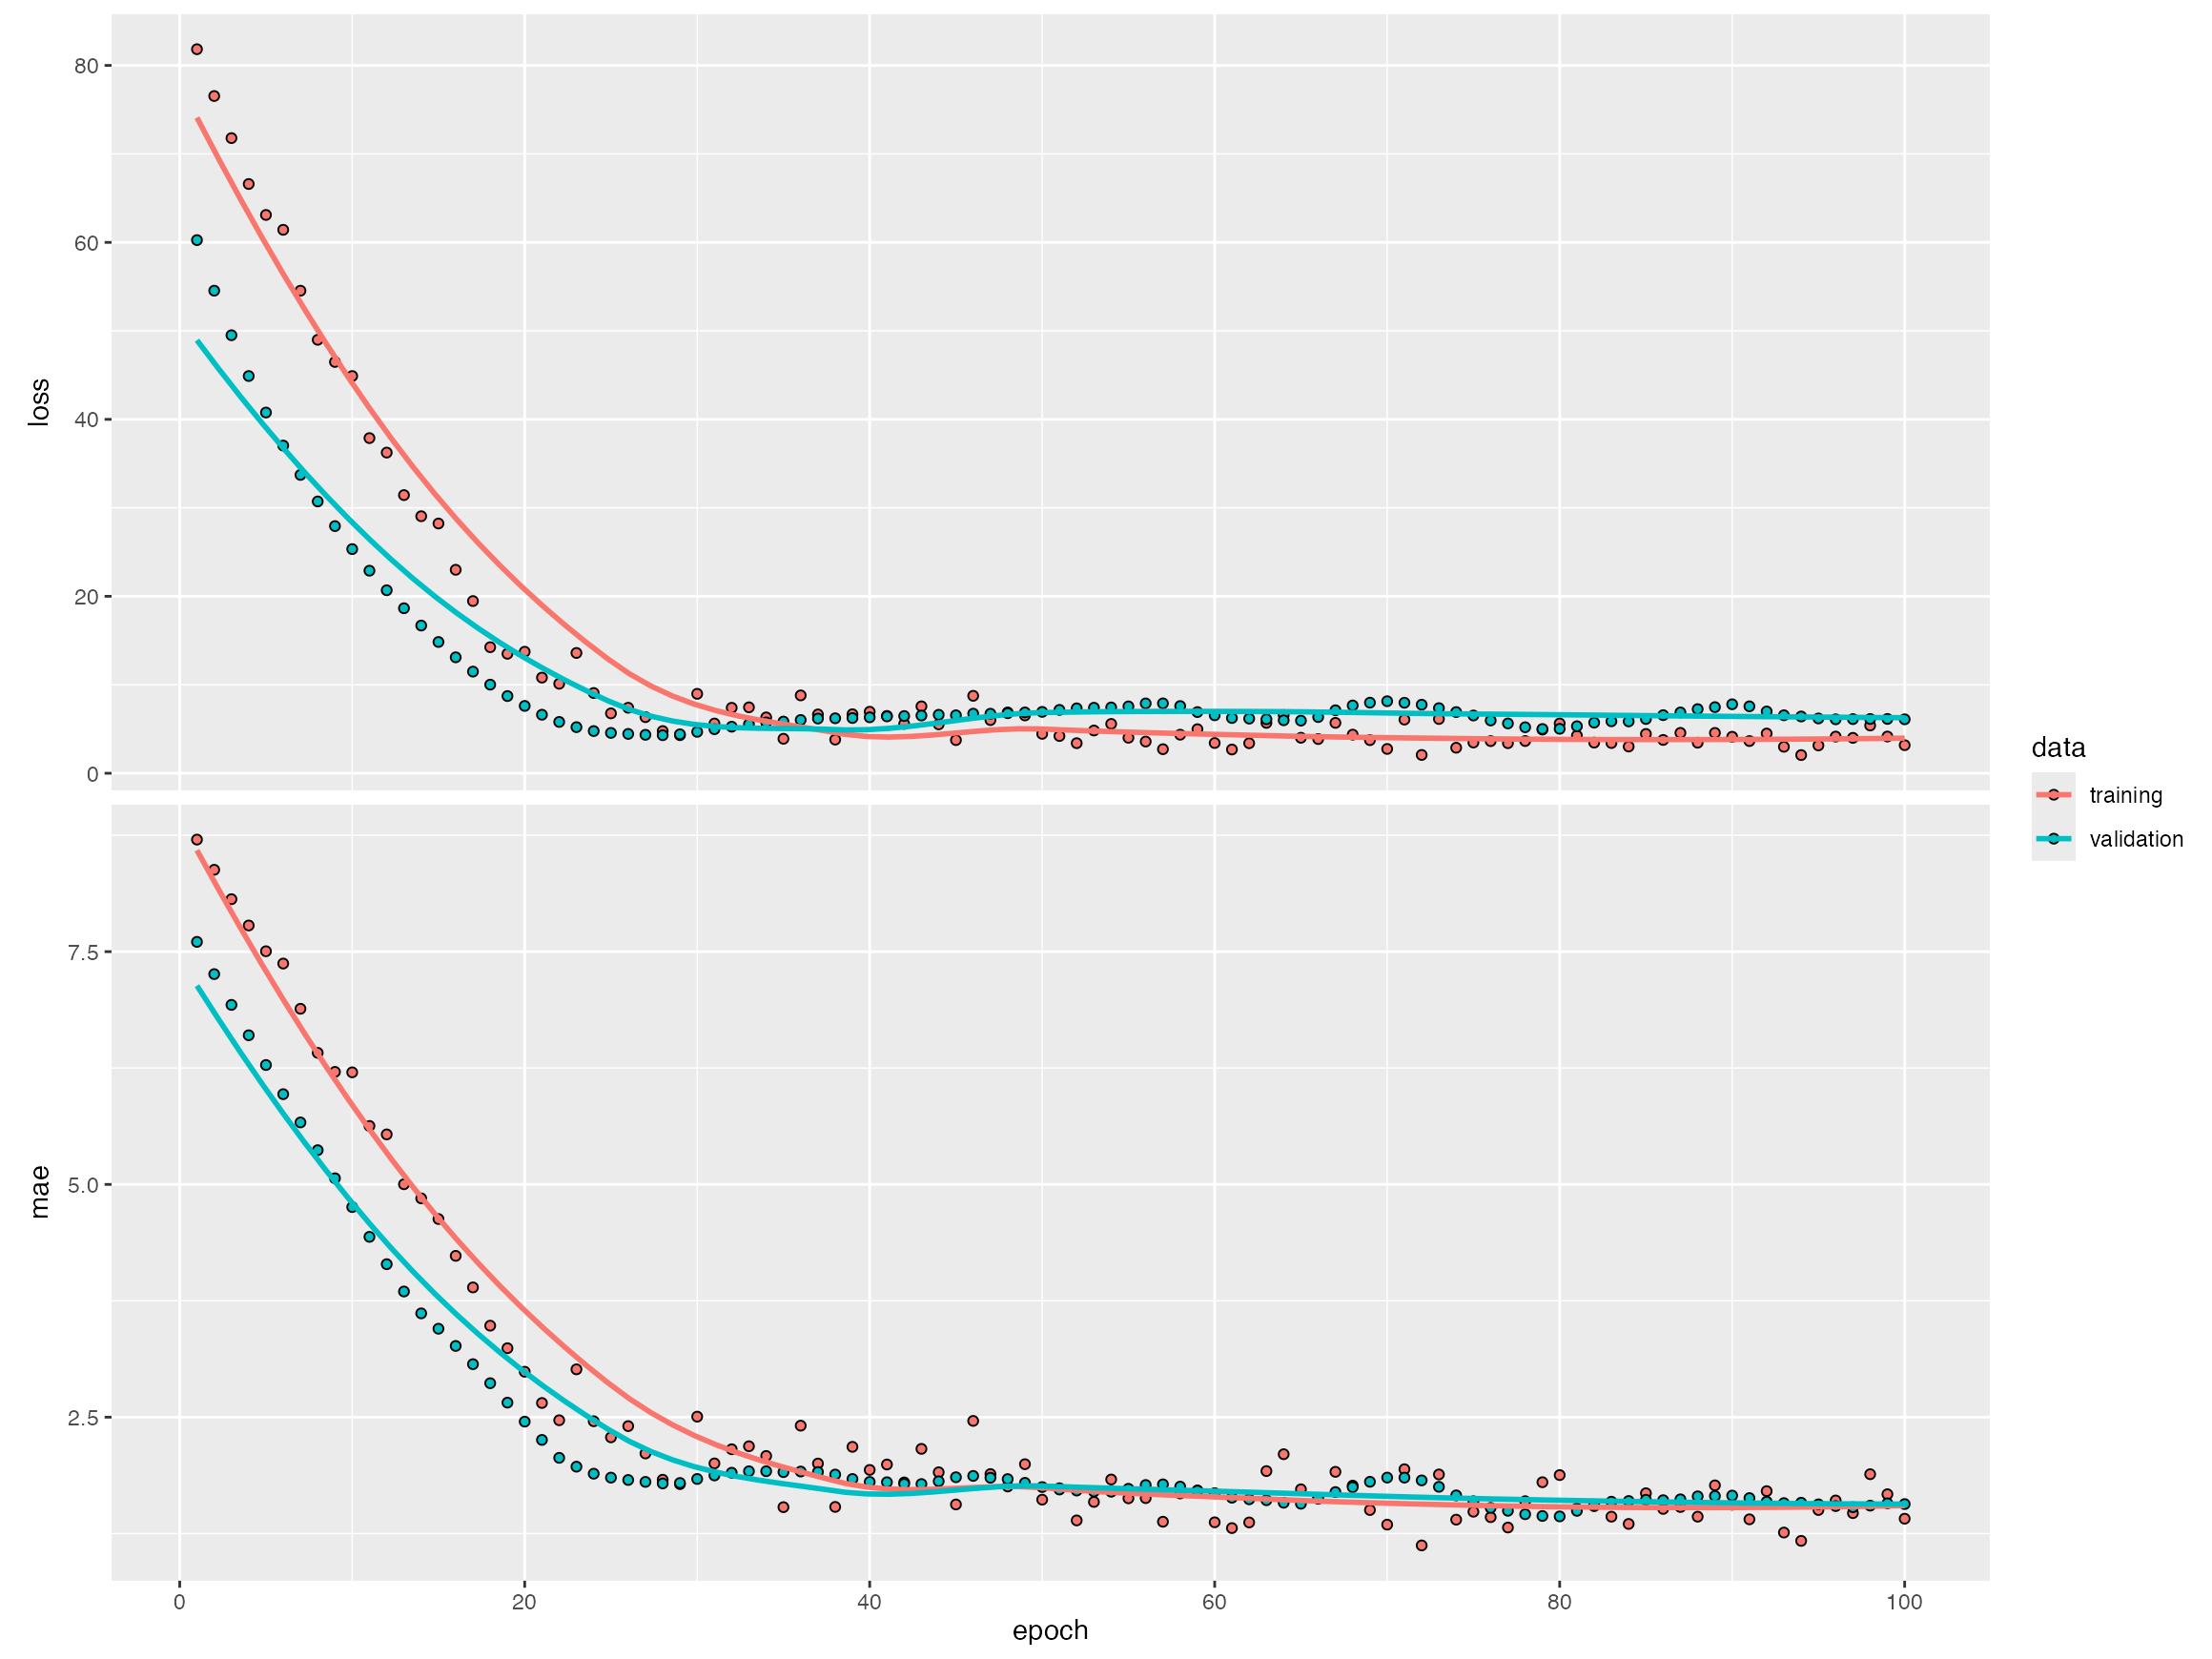

In [10]:
# Train model
history <- nn_model %>% fit(
  X_train_scaled, y_train,
  epochs = 100,
  batch_size = 8,
  validation_split = 0.2,
  verbose = 1
)

plot(history)

In [11]:
summary(nn_model)

Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                             ┃ Output Shape                                           ┃                         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                                                            │ (None, 64)                                             │                           1,920 │
├──────────────────────────────────────────────────────────────────────────┼────────────────────────────────────────────────────────┼─────────────────────────────────┤
│ dropout (Dropout)                                                        │ (None, 64)                                             │       


##4. L2 Regularization ##


In [12]:
 l2_lambda <- 0.05  # Regularization strength (can tune this)

  nn_model_l2 <- keras_model_sequential() %>%
    layer_dense(units = 64,
                activation = "relu",
                input_shape = ncol(X_train_scaled),
                kernel_regularizer = regularizer_l2(l2_lambda)) %>%
    layer_dropout(rate = 0.25) %>%
    layer_dense(units = 32,
                activation = "relu",
                kernel_regularizer = regularizer_l2(l2_lambda)) %>%
    layer_dropout(rate = 0.25) %>%
    layer_dense(units = 1,
                kernel_regularizer = regularizer_l2(l2_lambda))

  summary(nn_model_l2)

Model: "sequential_1"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                             ┃ Output Shape                                           ┃                         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                                                          │ (None, 64)                                             │                           1,920 │
├──────────────────────────────────────────────────────────────────────────┼────────────────────────────────────────────────────────┼─────────────────────────────────┤
│ dropout_2 (Dropout)                                                      │ (None, 64)                                             │     

In [13]:
  # Compile model with L2 regularization
  nn_model_l2 %>% compile(
    loss = "mse",
    optimizer = optimizer_adam(learning_rate = 0.001),
    metrics = c("mae")
  )

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 78.4503 - mae: 8.3493 - val_loss: 62.3467 - val_mae: 7.4373
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 74.3453 - mae: 8.1008 - val_loss: 58.1619 - val_mae: 7.1753
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 66.5861 - mae: 7.6603 - val_loss: 54.0537 - val_mae: 6.9071
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 65.0560 - mae: 7.5085 - val_loss: 50.0047 - val_mae: 6.6301
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 61.1056 - mae: 7.2263 - val_loss: 45.8658 - val_mae: 6.3339
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 50.7340 - mae: 6.5411 - val_loss: 41.8298 - val_mae: 6.0250
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 45.8333 - mae: 6.2268 - val_loss: 37.9107 - val_mae: 5.7025
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 42.4824 - mae: 5.9187 - val_loss: 34.1366 - val_mae: 5.3688
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 38.584

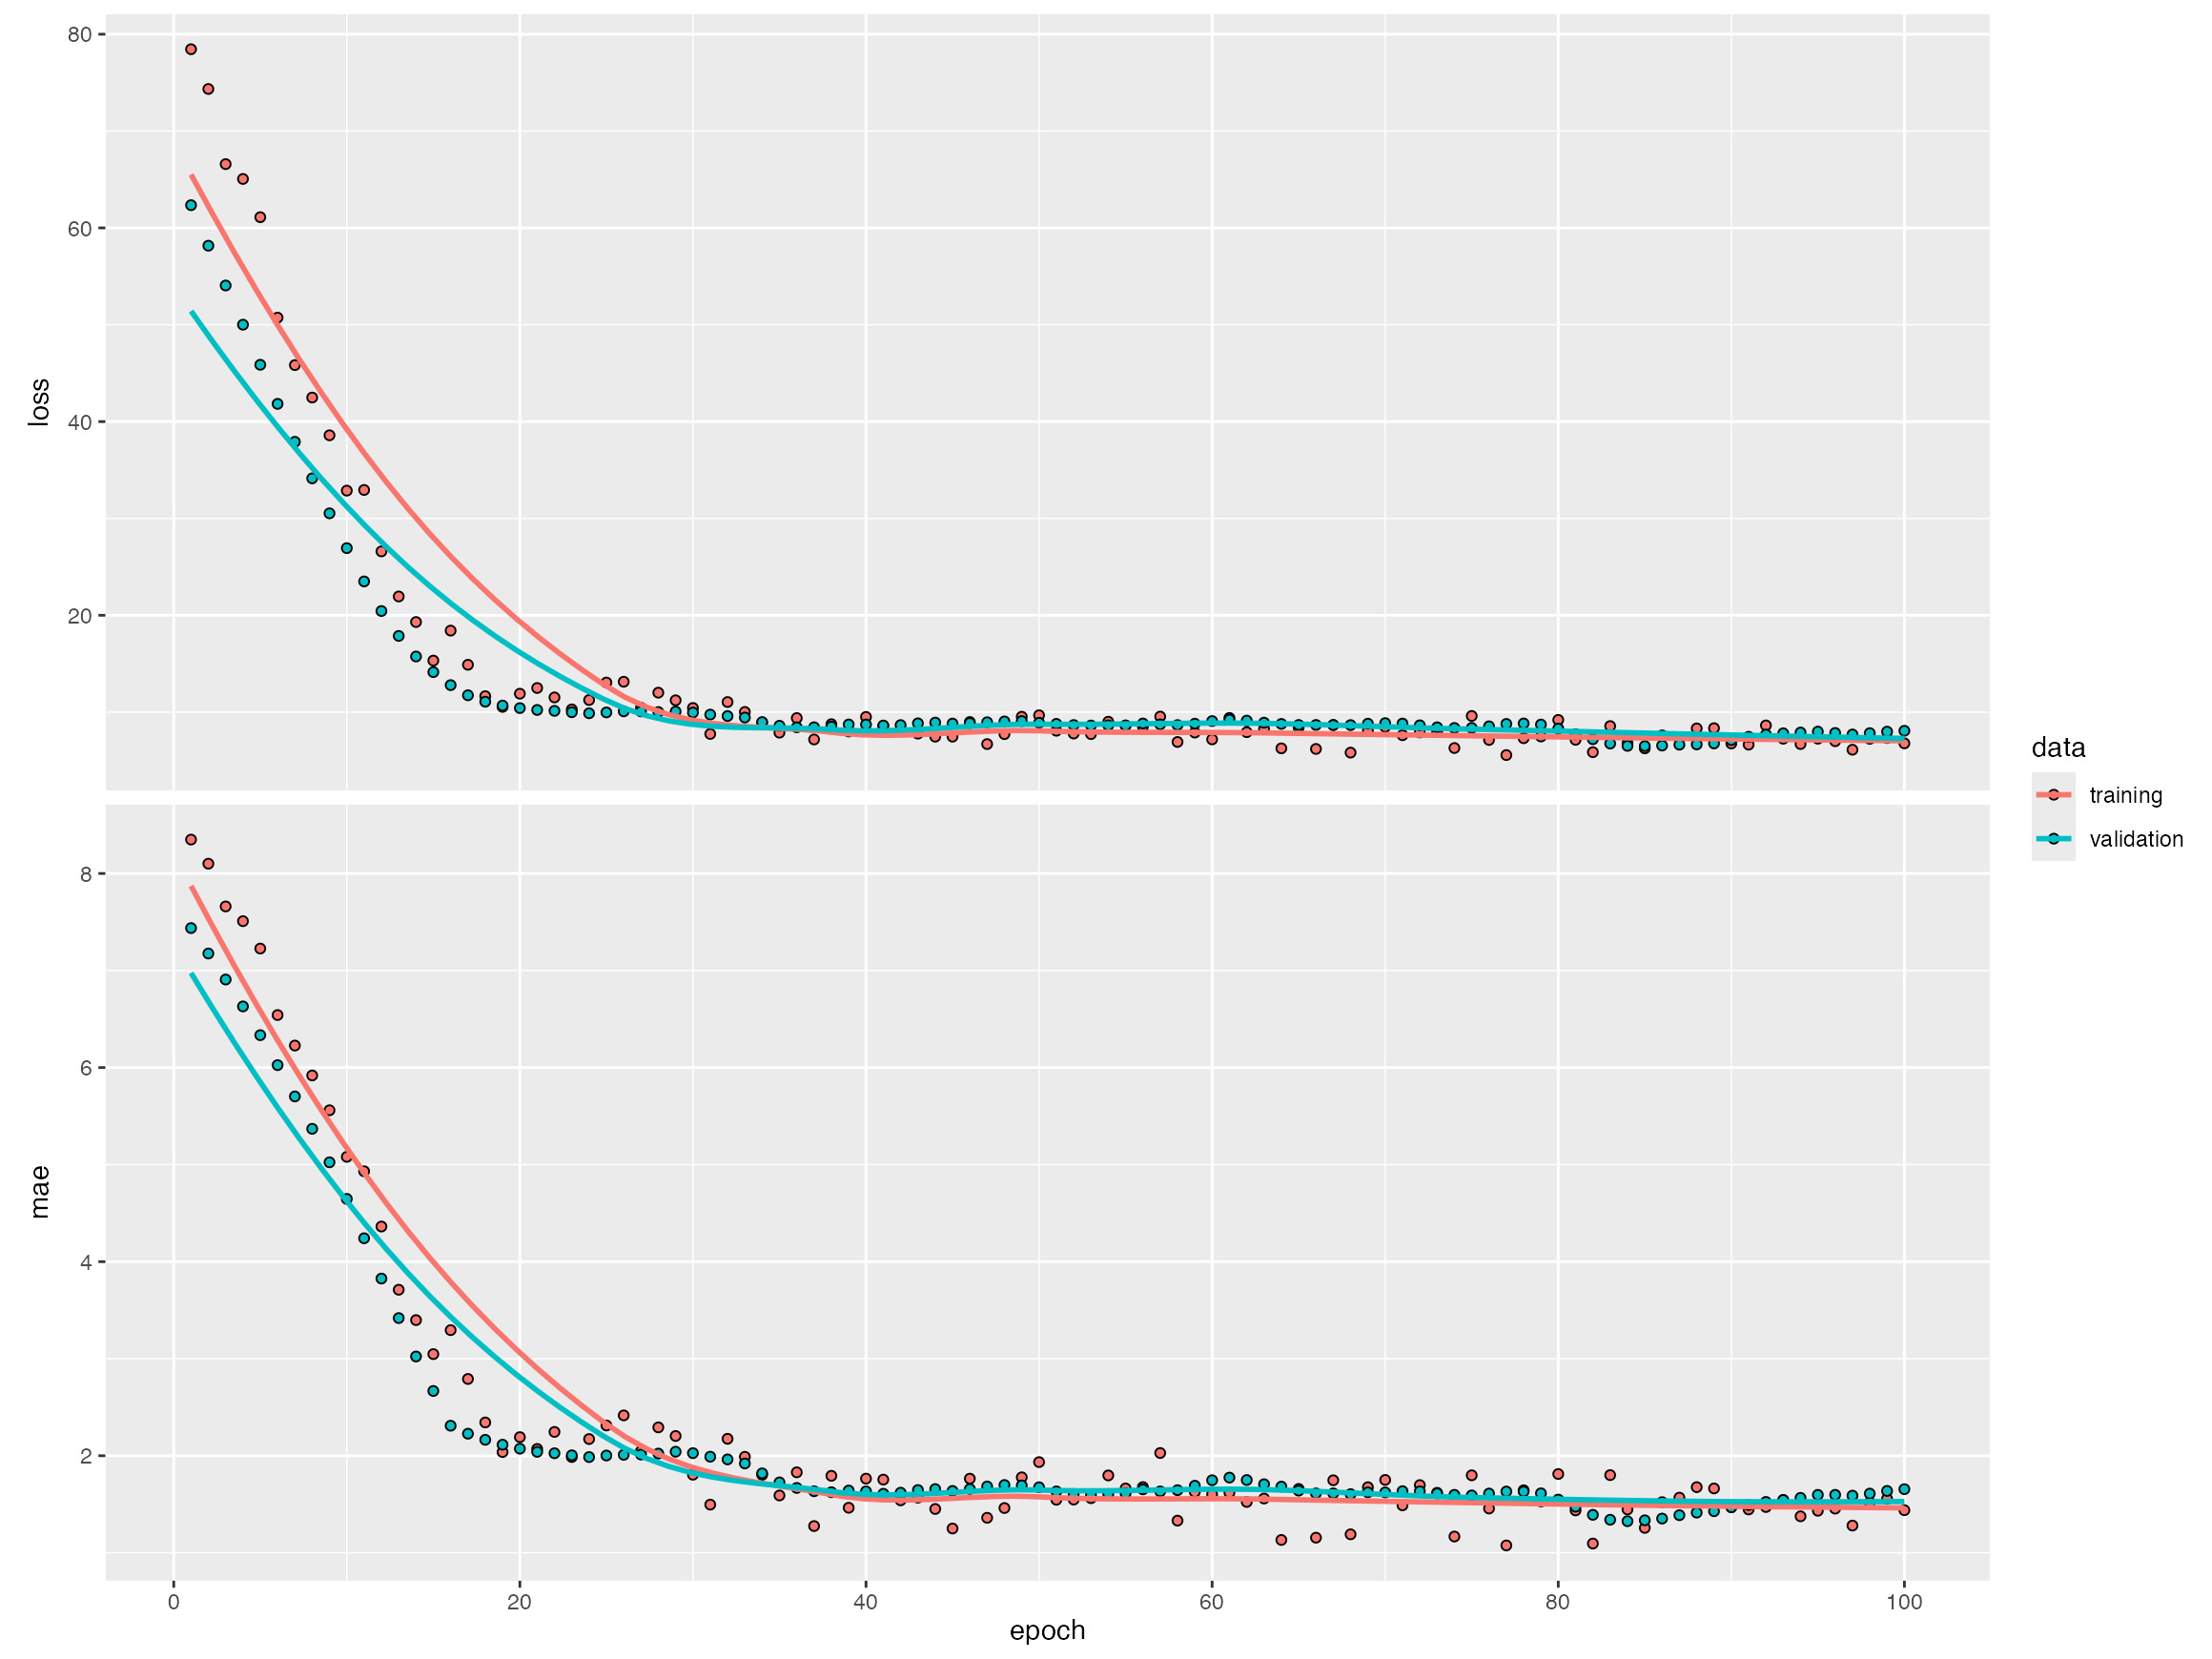

In [14]:
  # Train model with L2 regularization
  history_l2 <- nn_model_l2 %>% fit(
    X_train_scaled, y_train,
    epochs = 100,
    batch_size = 8,
    validation_split = 0.2,
    verbose = 1
  )

  plot(history_l2)

In [17]:
# Evaluate original model
  pred_original <- nn_model %>% predict(X_test_scaled)
  rmse_original <- sqrt(mean((y_test - pred_original)^2))
  mae_original <- mean(abs(y_test - pred_original))
  r2_ori <- R2(pred_original, y_test)
  rss_ori <- sum((y_test - pred_original)^2)



  # Evaluate L2 regularized model
  pred_l2 <- nn_model_l2 %>% predict(X_test_scaled)
  rmse_l2 <- sqrt(mean((y_test - pred_l2)^2))
  mae_l2 <- mean(abs(y_test - pred_l2))
  r2_l2 <- R2(pred_l2, y_test)
  rss_l2 <- sum((y_test - pred_l2)^2)

  # Print comparison
  cat("Original Model:\n")
  cat("  RMSE:", rmse_original, "\n")
  cat("  R-squared:", r2_ori, "\n")
  cat("  MAE:", mae_original, "\n")
  cat("  RSS:", rss_ori, "\n\n")

  cat("L2 Regularized Model:\n")
  cat("  RMSE:", rmse_l2, "\n")
  cat("  R-squared:", r2_l2, "\n")
  cat("  MAE:", mae_l2, "\n")
  cat("  RSS:", rss_l2, "\n\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Original Model:
  RMSE: 0.9968233 
  R-squared: 0.8022476 
  MAE: 0.8124191 
  RSS: 10.93022 

L2 Regularized Model:
  RMSE: 1.106012 
  R-squared: 0.8030206 
  MAE: 0.9556546 
  RSS: 13.45589 



In [ ]:
models_dir <- "/Users/winniex/Desktop/WDS_2026_AI_HOME/Project/Models"                                                                                                         
  if (!dir.exists(models_dir)) {
    dir.create(models_dir, recursive = TRUE)                                                                                                                                                 
  }               

  model_path <- file.path(models_dir, "nn_model_l2_poverty_prediction.keras")
  save_model(nn_model_l2, model_path, overwrite=TRUE)

  cat("Model saved to:", model_path, "\n")

  preproc_path <- file.path(models_dir, "preprocessing_scaler.rds")
  saveRDS(preproc, preproc_path)

  cat("Preprocessing scaler saved to:", preproc_path, "\n")

Model saved to: /Users/winniex/Desktop/WDS/Project/Models/nn_model_l2_poverty_prediction.keras 
Preprocessing scaler saved to: /Users/winniex/Desktop/WDS/Project/Models/preprocessing_scaler.rds 
